# Activity 05: Hare and Lynx Simulated versus Real Populations

-------
## Overview
In this lesson you will simulate the populations of Snow Hares and Lynxes using a __for__ loop and compare them to the "exact" solution. 

The exercises in the notebook will show how to: 
1. Coding a __for loop__ and an __array__ to simulate the hare and lynx populations with different __timesteps__.
2. Plotting the Simulated populations on subplots.
3. Calculating the exact populations using an __exponential function__
4. Plotting the exact populations.
5. Calculating the __error__ of the simulated vs exact populations.
6. Plotting the __error__ of the simulated vs exact populations.
7. Interactive graph to illustrate how the size of the __timesteps__ impacts the error.

In [1]:
## Library

# Import NumPy for numerical operations and array handling
import numpy as np

# Import Matplotlib's pyplot module for plotting
import matplotlib.pyplot as plt

import matplotlib.gridspec as gridspec

from ipywidgets import interact, FloatSlider

# Enable inline plotting in Jupyter notebooks so plots appear directly below the code cells
%matplotlib inline

# Import the warnings module to manage warning messages (e.g., suppress or customize them)
import warnings



## Time Step 
In the previous two lessons we have used a time step of one-year, 1, to predict the Hare and Lynx populations using recurrent equations: 
$$\textcolor{red}{H}= H + r_{Birth}  H, $$
$$\textcolor{red}{L}= L - r_{Death}  L, $$
where $r_{Brith}$ is the birth rate of the Hares and $r_{Death}$ if they had no prey is the death rate of the Lynxes if they had no food.
These recurrent equations are re-written in array from as:
$$\textcolor{red}{H[i+1]}= H[i] + 1*(r_{Birth} * H[i]), $$
$$\textcolor{red}{L[i+1]}= L[i] - 1*(r_{Death} * L[i]), $$
with $i=0,...,N-1$.

Instead of a one-year timestep we want a half-year time step we just add \textcolor{blue}{timestep=0.5} and multiply it by the change in the population:
$$\textcolor{red}{H[i+1]}= H[i] + \textcolor{blue}{0.5}*(r_{Birth} * H[i]), $$
$$\textcolor{red}{L[i+1]}= L[i] - \textcolor{blue}{0.5}*(r_{Death} * L[i]), $$
with $i=0,...,N-1$.

### Calculations
To estimate the populations after half a year, suppose:
* Hare population, H=85, birth rate, $r_{Birth}=0.2$,
* Lynx population, L=51, death rate, $r_{Death}=0.1$

Then:
$$93.5  = 85 + 0.5*0.2 * 85, $$
$$48.45= 51 - 0.5*0.1 * 51. $$
After half a year in 1895.5, the simlated hare population increases to $93.5$, while the simulate lynx population decreases to $48.45$.

To estimate the populations a second half years in the future :
$$103.819  = 93.5  + 0.5*0.2 * 93.5 , $$
$$46.1467= 48.45 - 0.5*0.1 * 48.45. $$
So in 1896, the simualte hare population increases to 93.5, while the simulated lynx population decreases to 48.45.

In [2]:
# Set the timestep for the simulation (0.5 year per step)
timestep = 0.5

# Create an array of years from 1895 to 1915 (inclusive) with the given timestep
time = np.arange(1895, 1915+ timestep/2, timestep)

# Calculate the number of time steps (years)
N = len(time)

# Initialize an array to store the lynx population at each time step
L = np.zeros(N)

# Initialize an array to store the hare population at each time step
H = np.zeros(N)

r_birth=0.2 # Hare Birth Rate
r_death=0.1 # Lynx Death Rate

L[0]=51 # Start Population
H[0]=85 # Start Population


### Coding Exercise 5.1: Recurrent Equations with for loop
The hare and lynx populations are updated at each time step using the recurrent equations:
$$H[i+1]= H[i] + timestep*(r\_birth * H[i]), $$
$$L[i+1]= L[i] - timestep*(r\_death * L[i]), $$
where $i$ starts at $0$ and goes to the length of the array, $N-1$, and the timestep is $0.5$. 

Code the reccurent equation.

In [3]:
# Loop through each time step to compute the 
# hare and lynx populations using the recurrence equations

for i in range(0, N-1):
    ### Coding Solution 5.1: Recurrent equations for hares and lynx
    H[i+1] = H[i] + timestep * (r_birth * H[i])
    L[i+1] = L[i] - timestep * (r_death * L[i])

print(' Simulated Hare Population in 1915: ', H[-1], ' \n Simulated Lynx Population in 1915: ', L[-1])

 Simulated Hare Population in 1915:  3847.0367232949557  
 Simulated Lynx Population in 1915:  6.554119984820269


### Coding Exercise 5.2: Plotting the Simulated Population Data

#### Coding Exercise 5.2a: Plotting the Simulated Hare Population Data

In the left subplot: 
* plot the simulated Hare population, H, as a dotted ':' green line, as a function of time. 

#### Coding Exercise 5.4b: Plotting the Exact Lynx Population Data

In the right subplot:
* plot the simulated Lynx population, L, as a dotted ':' red line, as a function of time.

Hint: use the __axes[0].plot(x,y,':',label='y (Simulated)')__ for the left subplot and __axes[1].plot(x,y,':',label='y (Simulated)')__ for the right subplot function.

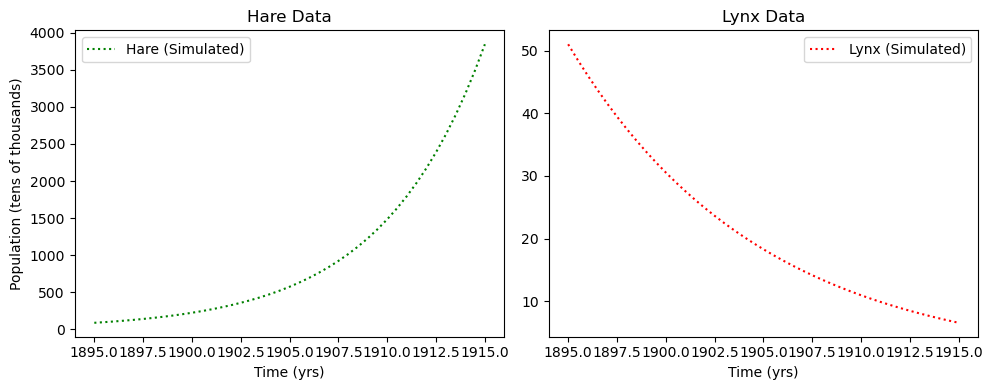

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)
# --- Subplot 1: Hare Data ---

### Solution Coding Exercise 5.2a
axes[0].plot(time, H, ':', label='Hare (Simulated)', color='green')
###


axes[0].set_title('Hare Data')# Add a title to the hare subplot
axes[0].set_xlabel('Time (yrs)') # Label the x-axis as time in years
axes[0].set_ylabel('Population (tens of thousands)') # Label the y-axis as population size (in tens of thousands)
axes[0].legend() # Display the legend for the hare plot


# --- Subplot 2: Lynx Data ---
### Solution Coding Exercise 5.2b
axes[1].plot(time, L, ':', label='Lynx (Simulated)', color='red')
###

axes[1].set_title('Lynx Data') # Add a title to the lynx subplot
axes[1].set_xlabel('Time (yrs)') # Label the x-axis as time in years
axes[1].legend() # Display the legend for the lynx plot
plt.tight_layout() # Adjust subplot spacing to prevent overlap

plt.show()

## Exact Solution

For simple populations the __exact solution__ can be calculated using the population-growth equation that looks like: $$P_Ie^{rt},$$
where $r$ is the the population birth or death rate impacts the population and $P_I$ is the initial population.

The exponential term, $e$, models how a population changes by the same rate over time, so it grows or declines faster and faster. 

### Code Exercise 5.3 :Exact Solution
Using the initial populations:
* Initial hare population = 85,  birth rate, $r_{Birth}=0.2$,
* Initial lynx population = 51, death rate, $r_{Death}=0.1$,
the exact solutions are:

$$Hare=85\times e^{r_{birth}t}, $$
$$Lynx=51\times e^{-r_{death}t}, $$

where Hare and Lynx are the exact populations, $t$ is time, which can be coded as time-time[0] to make the first year, 1895, year 0.

Hint:
To code an exponential in python you use the function __np.exp()__:
$ P\_I*np.exp(r*t). $


In [5]:
### Solution Coding Exercise 5.3 
HARE=H[0]*np.exp(r_birth*(time-time[0]))
LYNX=L[0]*np.exp(-r_death*(time-time[0]))
###

print(' Exact Hare Population in 1915: ', HARE[-1], ' \n Exact Lynx Population in 1915: ', LYNX[-1]) 

 Exact Hare Population in 1915:  4640.84275281726  
 Exact Lynx Population in 1915:  6.902099445067248


### Coding Exercise 5.4: Plotting the Simulated and Exact Population Data

#### Coding Exercise 5.4a: Plotting the Exact Hare Population Data

In the left subplot: 
* plot the exact Hare population, HARE, as a dashed '--' green line,
  
as a function of time. 

#### Coding Exercise 5.4b: Plotting the Exact Lynx Population Data

In the right subplot:
* plot the exact Lynx population, LYNX, as a dashed '--' red line,
  
as a function of time. 

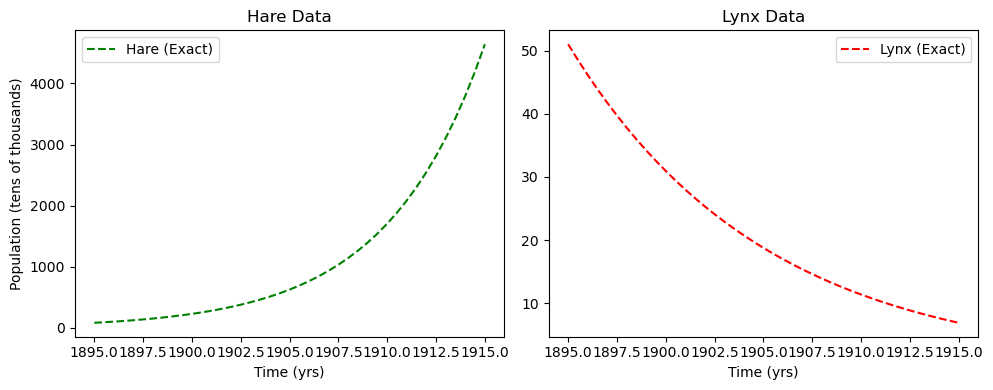

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# --- Subplot 1: Hare Data ---

### Solution Coding Exercise 5.4a
axes[0].plot(time, HARE, '--', label='Hare (Exact)', color='green')
###

axes[0].set_title('Hare Data')
axes[0].set_xlabel('Time (yrs)')
axes[0].set_ylabel('Population (tens of thousands)')
axes[0].legend()

# --- Subplot 2: Lynx Data ---
### Solution Coding Exercise 5.4b
axes[1].plot(time, LYNX, '--', label='Lynx (Exact)', color='red')
###

axes[1].set_title('Lynx Data')
axes[1].set_xlabel('Time (yrs)')
axes[1].legend()

plt.tight_layout()
plt.show()

### Coding Exercise 5.5: Plotting the Simulated and Exact Population Data

#### Coding Exercise 5.5a: Plotting the Simulated and Exact Hare Population Data

In the left subplot: 
* plot the simulated Hare population, H, as a dotted green line,
* plot the exact Hare population, HARE, as a dashed green line,
  
as a function of time. 

#### Coding Exercise 5.5b: Plotting the Simulated and Exact Lynx Population Data

In the right subplot:
* plot the simulated Lynx population, L, as a dotted red line, 
* plot the exact Lynx population, LYNX, as a dashed red line,
  
as a function of time. 

__Hint__: you can copy and paste from coding Exercise 5.2 and 5.4.

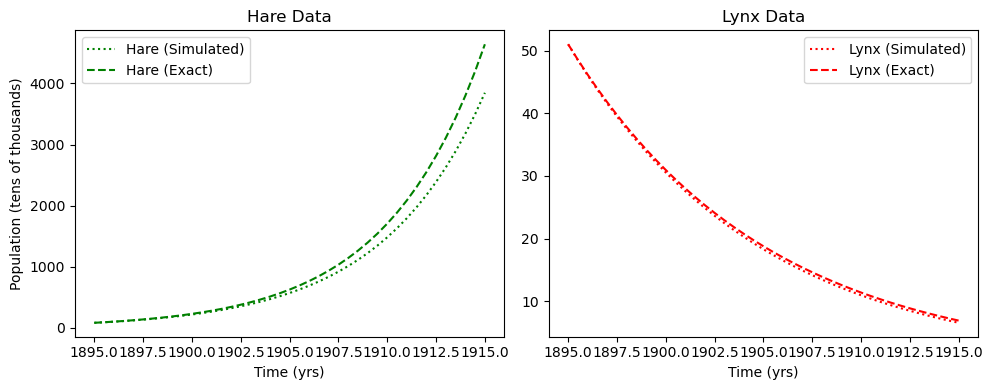

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# --- Left Subplot 1: Hare Data ---

### Solution Coding Exercise 5.5a
axes[0].plot(time, H, ':', label='Hare (Simulated)', color='green')
axes[0].plot(time, HARE, '--', label='Hare (Exact)', color='green')
###

axes[0].set_title('Hare Data')
axes[0].set_xlabel('Time (yrs)')
axes[0].set_ylabel('Population (tens of thousands)')
axes[0].legend()

# --- Right Subplot 2: Lynx Data ---
### Solution Coding Exercise 5.5b
axes[1].plot(time, L, ':', label='Lynx (Simulated)', color='red')
axes[1].plot(time, LYNX, '--', label='Lynx (Exact)', color='red')
###

axes[1].set_title('Lynx Data')
axes[1].set_xlabel('Time (yrs)')
axes[1].legend()

plt.tight_layout()
plt.show()


## Calculating Error

To calculate the error, $e$ between the exact and the simulated you just subtract them from each other,
$$ e_{Hare}=H-Hare, $$
$$ e_{Lynx}=L-Lynx, $$
this gives the error at every time point.

### Absolute Error

The size of the error is the most important thing not if it negative or positive. So you take the absolute value of the error,
$$ e\_Hare=|H-HARE|, $$
$$ e\_Lynx=|L-LYNX|. $$

This tells us how far the simulated population is from the exact population at each time point.

### Coding Exercise 5.6.1: Calculating the Error

Calculate the absolute error by subtracting the simulated from the exact populations for both hare and lynx populations using the function __np.abs()__.


In [8]:
### Solution Coding Exercise 5.6.1
e_Hare= np.abs(H-HARE)
e_Lynx= np.abs(L-LYNX)
###

print(' Error in Hare Population in 1915: ', e_Hare[-1], ' \n Error in Lynx Population in 1915: ', e_Lynx[-1]) 

 Error in Hare Population in 1915:  793.806029522304  
 Error in Lynx Population in 1915:  0.3479794602469788


### Coding Exercise 5.6.2: Plotting the Error
#### Coding Exercise 5.6.2a: Plotting the error for the Hare Population Data

In the left subplot: 
* plot the error in the Hare population, e_Hare, as a dash-dot green line,  
as a function of time. 

#### Coding Exercise 5.6.2b: Plotting the error for the Lynx Population Data

In the right subplot:
* plot the error in the Lynx population, e_Lynx, as a dash-dot red line,    
as a function of time. 

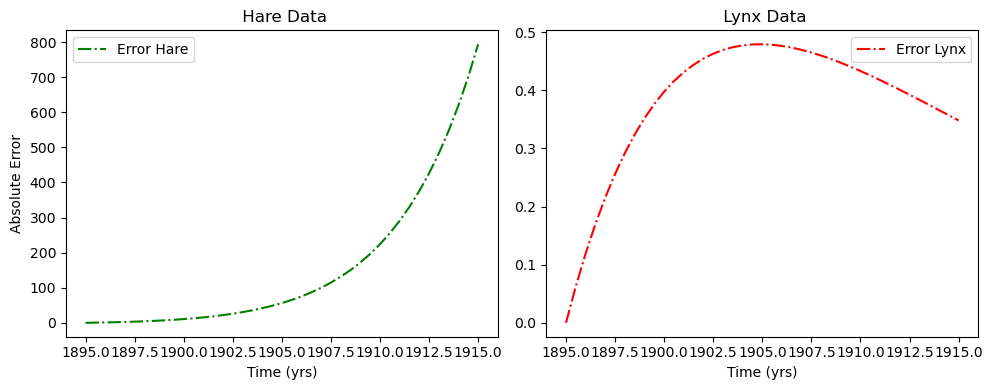

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# --- Left Subplot 1: Real Data ---
### Coding Solution 5.6.2a
axes[0].plot(time, e_Hare, '-.', label='Error Hare', color='green')
###
axes[0].set_title(' Hare Data')
axes[0].set_xlabel('Time (yrs)')
axes[0].set_ylabel('Absolute Error')
axes[0].legend()

# --- Right Subplot 2: Simulated Data ---
### Coding Solution 5.6.2b
axes[1].plot(time, e_Lynx, '-.', label='Error Lynx', color='red')
###
axes[1].set_title(' Lynx Data')
axes[1].set_xlabel('Time (yrs)')
axes[1].legend()
plt.tight_layout()
plt.show()

## Reflective Exercise 5.7: Time steps

The interactive plot below shows the exact (dashed) and simulated (dots) populations of Hares (green) and lynxes (red). The two lower plots shows the error (exact-simlated) for the Hare population (left) and the Lynx population (right).

Use the sliders to change the time step from 0.1 to 1. 
Reflect on how each change impacts:
* The simulated hare and lynx populations.
* The error between the exact and simulated results.

In [22]:
# Function to simulate hare and lynx population dynamics
def hare_lynx_simulation(timestep=0.1):
    # Simulation parameters
    r_birth=0.2 
    r_death=0.1
    time = np.arange(1895, 1915.1, timestep)  # Time range from 1895 to 1915
    N = len(time)  # Number of time steps

    # Initialize population arrays
    L = np.zeros(N)  # Lynx population over time
    H = np.zeros(N)  # Hare population over time
    L[0], H[0] = 51, 85  # Starting populations (in tens of thousands)

    # Analytical solutions for exponential growth/decay
    LYNX = L[0] * np.exp(-r_death * (time - time[0]))  # Lynx decay
    HARE = H[0] * np.exp(r_birth * (time - time[0]))   # Hare growth

    # Numerical simulation using Euler's method
    for i in range(N - 1):
        L[i + 1] = L[i] + timestep * (-r_death * L[i])  # Lynx decreases
        H[i + 1] = H[i] + timestep * (r_birth * H[i])   # Hare increases


    # Create figure and grid
    fig = plt.figure(figsize=(8, 6))
    gs = gridspec.GridSpec(2, 2)

    # Top-left subplot: Hare population
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(time, H, ':', color='green', label='Hare (Simulation)')
    ax1.plot(time, HARE, '--', color='green', label='Hare (Exact)')
    ax1.set_xlabel('Time (years)')
    ax1.set_ylabel('Hare Population\n(tens of thousands)')
    ax1.legend()

    # Top-right subplot: Lynx population
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(time, L, ':', color='red', label='Lynx (Simulation)')
    ax2.plot(time, LYNX, '--', color='red', label='Lynx (Exact)')
    ax2.set_xlabel('Time (years)')
    ax2.set_ylabel('Lynx Population\n(tens of thousands)')
    ax2.legend()

    # Bottom-left subplot: Hare error
    ax3 = fig.add_subplot(gs[1, 0])
    ax3.plot(time, np.abs(H - HARE), '-.', color='green')
    ax3.set_xlabel('Time (years)')
    ax3.set_ylabel('Hare Absolute Error')

    # Bottom-right subplot: Lynx error
    ax4 = fig.add_subplot(gs[1, 1])
    ax4.plot(time, np.abs(L - LYNX), '-.', color='red')
    ax4.set_xlabel('Time (years)')
    ax4.set_ylabel('Lynx Absolute Error')

    # Improve spacing
    plt.tight_layout()
    plt.show()

    

In [23]:
# Interactive sliders for birth and death rates
interact(hare_lynx_simulation,
         timestep=FloatSlider(min=0.1, max=1, step=0.1, value=0.1, description='Time Step'))

interactive(children=(FloatSlider(value=0.1, description='Time Step', max=1.0, min=0.1), Output()), _dom_class…

<function __main__.hare_lynx_simulation(timestep=0.1)>

## Summary and Outro 

* The Simulated and Exact populations have a similar shape.
* The error shows that the simulated and exact are not perfectly matched.
* The smaller the time step the smaller the error.

### Next Lesson
* The Hare and Lynx populations will interact.

